# EDA, probabilidad de inserción laboral Panamá

In [66]:
!pip install -q pandas matplotlib seaborn pyreadstat
!pip install -q itables
!pip install linearmodels

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import warnings
from itables import show
import statsmodels.api as sm

warnings.filterwarnings('ignore')

In [68]:
# Subir archivo manualmente

from google.colab import files
uploaded = files.upload()

Saving 240322base de datos completa.sav to 240322base de datos completa (2).sav


In [69]:
# Carga de la base de datos
df, meta = pyreadstat.read_sav("240322base de datos completa.sav")

# Exploración de variables y tamaño de dataset

In [70]:
print(df.shape)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head(10)

(42925, 207)


,D_R,llave_sec,provincia,prov,unidad,cuest,hogar,nper,Jefe_de_hogar,p1a_otro,Sexo,Edad,Seguro_Social,p4a_ss_fic,p4b,p4c,p4c_otro,Persona_con_dispacidad,tipo_de_dispacidad,p4d,p4d_otro,p4f,p4f_otro,Estado_civil,p4o_pais,p4p_cuando,p4p_anio,Fondo_de_pensiones_privado,Asiste_a_la_escuela,Tipo_de_educación,p5_asistio,p5a,p5a_otro_m,p5b,Grado_alcanzado,Sabe_leer_y_escribir,p7_titulo,p7b,p7b_cuanto,p8_16,p11_meses,p08_16b_ot,p17,p18,p18a,p19,p20,p21,p21a_otro,p22a,p22b,p22c,p23,p24,p25,p25_otro,p26,Dónde_trabaja_o_trabajó,p27a_otro,p28,p29,p29a,p30,Lugar_de_trabajo,Tipo_de_contrato,p33_sit,p34,Trabaja_por_sueldo_fijo,p351,p354,p352,p355,p353,p356,Salario_efectivo_empleado,Salario_especies_empleado,p362a_tipo,Salario_efectivo_independiente,Salario_especie_independiente,p364a_tipo,Salario_autoconsumo,Cuantas_horas_trabajó,p38,p39a,p39b,Dónde_trabajó_otro_trabajo,p39d,Horas_trabajadas_en_otro_trabajo,Ingreso_otro_trabajo,Uso_celular_últimos_6_meses,Uso_computador_últimos_6_meses,Uso_internet_últimos_6_meses,p72a,p72b,p72c1,p72c2,p72c3,p72c4,p72c5,p72c7,p72c8,p72c6,p72c6_otro,p72d,p72e,p72f1,p72f2,p72f3,p72f4,p72g1,p72g2,p72g3,p72g4,p72g5,p72g6,p72h,p72i,p72k,p72l,p72m,fac15_e,Es_indígena,Área_geográfica,div_panama,pea_nea,desagreg,ocu_des,Ocupación_principal,p39a_reco,Actividad_económica,p39b_reco,grado_ap,horas_trabajadas,salario,ingreso,Tiene_CSS,Tiene_Contrato,Nivel_academico_rango,Nivel_academico_continuo,Tiene_ingresos_72a_l,Recibe_jubilacion_pension,Tiene_pension_AES,Salarios_efectivo_empleado_XIII,Salarios_totales_XIII_autocons,Salarios_totales_XIII_sin_autocons,Total_Ayudas,Total_Becas,Total_Subsidios,Tiene_Ayudas,Tiene_Becas,Tiene_Subsidios,v0_condici,v0_cond_ot,v1a_tipo_d,Tipo_de_vivienda,v1b_otra_t,v1b_pago_m,v1c_pagari,v1d_materi,v1e_materi,v1f_materi,v1g_cuarto,v1h_dormit,Obtiene_agua_para_beber,v1i_otra,v1i_pago_a,Instalaciones_agua_beber,v1j1_veran,v1j1_invie,v1j2_veran,v1j2_invie,Servicio_sanitario,v1k1_excre,v1l_uso_sa,v1m_basura,Combustible_para_cocinar,Alumbrado_vivienda,v1p_verano,v1p_invier,v1q_verano,v1q_invier,cuantos_ho,area,Tiene_televisor,h2a1_nu_tv,Televisor_cable,Tiene_celular,h2b1_num,Teléfono_fijo,h2d_pub,h2e_radio,Tiene_refrigeradora,Tiene_computador,Computador_mesa,Laptop,Tablets,Tiene_internet_red_movil,Tiene_internet_red_fija,h5a_no_int,h5aa_no_ne,h5ab_otro_,h5ac_confi,h5ad_costo,h5ae_seg,h5af_zona,h5ag_otros,h5a_ot_raz
0,,1.0,01,01,001,01,1,01,1.0,,1.0,44.0,1.0,1.0,1.0,NaN,,2.0,NaN,11.0,,4.0,,1.0,001,,NaN,2.0,2.0,NaN,5.0,NaN,,NaN,53.0,1.0,3003.0,NaN,NaN,1.0,,,NaN,NaN,,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,,8322007,9.0,,4921,1.0,01,0.0,7.0,NaN,000095,207.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,1516.0,NaN,,NaN,63.0,3.0,,,NaN,NaN,NaN,NaN,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,48.0,1,Urbana,,PEA,Ocup,Ocupados,08,,08,,UNIV,,,,1.0,NaN,7.0,23.0,1.0,0.0,0.0,NaN,1516.0,1516.0,NaN,NaN,NaN,0.0,0.0,0.0,01,,2,01,,00150,,2,4,4,02,01,01,,9998,1,7,7,08,08,3,NaN,1,01,1.0,01,1,1,2,2,1,U,1,01,1,1,0,2,2,2,1,2,,,,1,2,,,,,,,,,
1,,1.0,01,01,001,01,1,02,2.0,,2.0,21.0,2.0,NaN,1.0,NaN,,2.0,NaN,2.0,,8.0,,1.0,001,,NaN,2.0,2.0,NaN,5.0,NaN,,NaN,36.0,1.0,1035.0,NaN,NaN,2.0,,,NaN,NaN,,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,,5121004,1.0,,5611,3.0,,NaN,4.0,3.0,000095,202.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,600.0,NaN,,NaN,NaN,,NaN,48.0,3.0,,,NaN,NaN,NaN,NaN,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,NaN,NaN,NaN,48.0,1,Urbana,,PEA,Ocup,Ocupados,05,,09,,S4A6,40 y mßs,07,07,0.0,0.0,5.0,18.0,0.0,0.0,0.0,650.0,650.0,650.0,NaN,NaN,NaN,0.0,0.0,0.0,01,,2,01,,00150,,2,4,4,02,01,01,,9998,1,7,7,08,08,3,NaN,1,01,1.0,01,1,1,2,2,1,U,1,01,1,1,0,2,2,2,1,2,,,,1,2,,,,,,,,,
2,,1.0,01,01,001,01,1,03,3.0,,1.0,4.0,2.0,NaN,1.0,NaN,,2.0,NaN,2.0,,4.0,,8.0,001,,NaN,NaN,2.0,NaN,6.0,3.0,,NaN,1.0,NaN,NaN,NaN,NaN,NaN,,,NaN,NaN,,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,NaN,,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

Al realizar la carga del dataset, se obtuvieron 42925 registros y 207 variables

In [71]:
print("\nInformación general del dataset")
df.info()


Información general del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42925 entries, 0 to 42924
Columns: 207 entries, D_R to h5a_ot_raz
dtypes: float64(110), object(97)
memory usage: 67.8+ MB


In [72]:
columnas = list(df.columns)

for columna in df.columns:
  print(f"{columna}: {df[columna].dtype}")

D_R: object
llave_sec: float64
provincia: object
prov: object
unidad: object
cuest: object
hogar: object
nper: object
Jefe_de_hogar: float64
p1a_otro: object
Sexo: float64
Edad: float64
Seguro_Social: float64
p4a_ss_fic: float64
p4b: float64
p4c: float64
p4c_otro: object
Persona_con_dispacidad: float64
tipo_de_dispacidad: float64
p4d: float64
p4d_otro: object
p4f: float64
p4f_otro: object
Estado_civil: float64
p4o_pais: object
p4p_cuando: object
p4p_anio: float64
Fondo_de_pensiones_privado: float64
Asiste_a_la_escuela: float64
Tipo_de_educación: float64
p5_asistio: float64
p5a: float64
p5a_otro_m: object
p5b: float64
Grado_alcanzado: float64
Sabe_leer_y_escribir: float64
p7_titulo: float64
p7b: float64
p7b_cuanto: float64
p8_16: float64
p11_meses: object
p08_16b_ot: object
p17: float64
p18: float64
p18a: object
p19: float64
p20: float64
p21: float64
p21a_otro: object
p22a: float64
p22b: float64
p22c: float64
p23: float64
p24: float64
p25: float64
p25_otro: object
p26: object
Dónde_trab

Se realiza una exploración de estas variables y sus tipos de datos para tener una idea de las que podemos utilizar en los modelos

In [73]:
df_modelo = df.copy()

# Selección de variables a utilizar en el modelo

Salario por Hora

In [74]:
# Copia del dataset
df = df.copy()

In [75]:
# Variables del hogar
id_hogar = ['llave_sec', 'provincia', 'prov', 'unidad', 'cuest', 'hogar']

# Eliminar columnas de hogar si ya existen en df_modelo
cols_hogar = ['ingreso_hogar', 'personas', 'niños', 'adultos_mayores', 'dependencia', 'ingreso_per_capita']
df_modelo = df_modelo.drop(columns=cols_hogar, errors='ignore')

# Variables auxiliares
df_modelo['niño'] = (df_modelo['Edad'] < 15).astype(int)
df_modelo['adulto_mayor'] = (df_modelo['Edad'] >= 65).astype(int)

# Reemplazar nulos por 0
df_modelo['Salario_efectivo_empleado'] = df_modelo['Salario_efectivo_empleado'].fillna(0)
df_modelo['Salario_efectivo_independiente'] = df_modelo['Salario_efectivo_independiente'].fillna(0)

# Crear ingreso total individual
df_modelo['ingreso_total_individual'] = (
    df_modelo['Salario_efectivo_empleado'] + df_modelo['Salario_efectivo_independiente']
)

# Dataset agregado por hogar
hogar = df_modelo.groupby(id_hogar).agg(
    ingreso_hogar=('ingreso_total_individual', 'sum'),
    personas=('Edad', 'count'),
    niños=('niño', 'sum'),
    adultos_mayores=('adulto_mayor', 'sum')
).reset_index()

# Indicadores del hogar
hogar['dependencia'] = (hogar['niños'] + hogar['adultos_mayores']) / hogar['personas']
hogar['ingreso_per_capita'] = hogar['ingreso_hogar'] / hogar['personas']


# Unir variables del hogar al dataset individual
df_modelo = df_modelo.merge(hogar, on=id_hogar, how='left')

# Seleccionar variables finales
columnas_finales = id_hogar + [
    'Sexo',
    'Edad',
    'Jefe_de_hogar',
    'Asiste_a_la_escuela',
    'Grado_alcanzado',
    'ocu_des',
    'Salario_efectivo_empleado',
    'Salario_efectivo_independiente',
    'Recibe_jubilacion_pension',
    'Uso_internet_últimos_6_meses',
    'ingreso_hogar',
    'personas',
    'niños',
    'adultos_mayores',
    'dependencia',
    'ingreso_per_capita'
]

df_modelo_final = df_modelo[columnas_finales].copy()

df_modelo_final.head(6)


,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita
0,1.0,01,01,001,01,1,1.0,44.0,1.0,2.0,53.0,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333
1,1.0,01,01,001,01,1,2.0,21.0,2.0,2.0,36.0,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333
2,1.0,01,01,001,01,1,1.0,4.0,3.0,2.0,1.0,,0.0,0.0,0.0,NaN,2116.0,3,1,0,0.333333,705.333333
3,2.0,01,01,001,02,1,2.0,22.0,1.0,2.0,36.0,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667
4,2.0,01,01,001,02,1,1.0,26.0,2.0,2.0,36.0,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667
5,2.0,01,01,001,02,1,1.0,3.0,3.0,NaN,NaN,,0.0,0.0,0.0,NaN,1550.0,3,1,0,0.333333,516.666667


In [76]:
# Borrar
# Agrupar edades sin crear nueva columna
grupos = pd.cut(
    df_modelo_final['Edad'],
    bins=[0, 17, 65, 120],
    labels=['< 18 años', '18 - 65 años', '> 65 años']
)

# Conteo
conteo = grupos.value_counts().sort_index()

# Porcentaje
porcentaje = grupos.value_counts(normalize=True).sort_index() * 100

# Resultado
distribucion = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})

distribucion

,Conteo,Porcentaje (%)
Edad,,
< 18 años,13259,31.37
18 - 65 años,24669,58.37
> 65 años,4337,10.26


In [77]:
#Transformación de variables númericas que representan categorías

df_modelo_final['Sexo'] = df_modelo_final['Sexo'].astype('category')
df_modelo_final['Jefe_de_hogar'] = df_modelo_final['Jefe_de_hogar'].astype('category')
df_modelo_final['Asiste_a_la_escuela'] = df_modelo_final['Asiste_a_la_escuela'].astype('category')
df_modelo_final['Grado_alcanzado'] = df_modelo_final['Grado_alcanzado'].astype('category')



In [78]:
print(df_modelo_final.shape)

(42925, 22)


In [79]:
df_modelo_final.dtypes

,0
llave_sec,float64
provincia,object
prov,object
unidad,object
cuest,object
hogar,object
Sexo,category
Edad,float64
Jefe_de_hogar,category
Asiste_a_la_escuela,category


In [80]:
print("\nEstadísticas descriptivas variables numéricas")
print(df_modelo_final.describe())

print("\nEstadísticas variables categóricas")
print(df_modelo_final.describe(include=['object', 'category']))




Estadísticas descriptivas variables numéricas
          llave_sec         Edad  Salario_efectivo_empleado  \
count  42925.000000  42925.00000               42925.000000   
mean    6107.211555     33.10530                 202.410600   
std     3618.800605     22.77738                 656.783603   
min        1.000000      0.00000                   0.000000   
25%     2879.000000     14.00000                   0.000000   
50%     6196.000000     30.00000                   0.000000   
75%     9326.000000     50.00000                  80.000000   
max    11934.000000    108.00000               77940.000000   

       Salario_efectivo_independiente  Recibe_jubilacion_pension  \
count                    42925.000000               42925.000000   
mean                        64.397065                   0.054351   
std                        410.486782                   0.226711   
min                          0.000000                   0.000000   
25%                          0.000000        

In [81]:
# =========================================
# Distribución de variables categóricas
# =========================================

variables_categoricas = [
    'Sexo',
    'Jefe_de_hogar',
    'Grado_alcanzado',
    'provincia',
    'Uso_internet_últimos_6_meses'
]

for var in variables_categoricas:

    print("\n==============================")
    print(f"Distribución de {var}")

    freq = df_modelo_final[var].value_counts()
    porcentaje = df_modelo_final[var].value_counts(normalize=True)*100

    tabla = pd.concat([freq, porcentaje], axis=1)
    tabla.columns = ['Frecuencia','Porcentaje']

    print(tabla)


Distribución de Sexo
      Frecuencia  Porcentaje
Sexo                        
2.0        21694   50.539313
1.0        21231   49.460687

Distribución de Jefe_de_hogar
               Frecuencia  Porcentaje
Jefe_de_hogar                        
3.0                 15963   37.188119
1.0                 12031   28.027956
4.0                  7680   17.891672
2.0                  6858   15.976704
6.0                   315    0.733838
5.0                    78    0.181712

Distribución de Grado_alcanzado
                 Frecuencia  Porcentaje
Grado_alcanzado                        
36.0                   6585   16.423085
16.0                   6429   16.034018
33.0                   3325    8.292598
1.0                    2619    6.531824
32.0                   1835    4.576516
13.0                   1642    4.095172
35.0                   1544    3.850758
31.0                   1478    3.686153
56.0                   1444    3.601357
15.0                   1404    3.501596
34.0          

In [82]:
# Verificación de valores nulos por columna (en porcentaje)
porcentaje_nulos = (df_modelo_final.isnull().sum() / len(df_modelo_final)) * 100
print(porcentaje_nulos)

llave_sec                          0.000000
provincia                          0.000000
prov                               0.000000
unidad                             0.000000
cuest                              0.000000
hogar                              0.000000
Sexo                               0.000000
Edad                               0.000000
Jefe_de_hogar                      0.000000
Asiste_a_la_escuela                6.590565
Grado_alcanzado                    6.590565
ocu_des                            0.000000
Salario_efectivo_empleado          0.000000
Salario_efectivo_independiente     0.000000
Recibe_jubilacion_pension          0.000000
Uso_internet_últimos_6_meses      17.232382
ingreso_hogar                      0.000000
personas                           0.000000
niños                              0.000000
adultos_mayores                    0.000000
dependencia                        0.000000
ingreso_per_capita                 0.000000
dtype: float64


Se realiza una análisis preliminar de los valores nulos y su porcentaje

<Axes: >

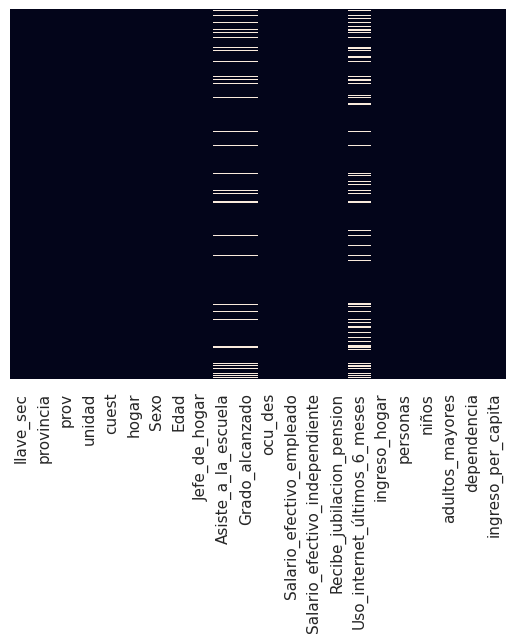

In [83]:
# Distribución de nulos por medio del color blanco
sns.heatmap(df_modelo_final.isnull(), cbar=False, yticklabels = False)

Para visualizar los valores nulos, nos ayudamos con este mapa de calor, marcándolos en blanco

# Recodificación de variables para mejor entendimiento

# Recodificación y dataset único de análisis

A partir de esta sección se trabaja con un solo dataframe principal: `df_analisis`.

Este dataframe contiene únicamente la población en edad laboral definida para el proyecto: personas con `Edad >= 18` y `Edad <= 65`.  
Las variables adicionales necesarias para EDA, Mincer, Heckman y modelos de Machine Learning se construyen dentro de este mismo dataframe.

In [84]:
# =========================================
# Dataset único para el análisis: 18 a 65 años
# =========================================

EDAD_MIN = 18
EDAD_MAX = 65

# Diccionarios de recodificación
dicc_sexo = {
    1: 'Masculino',
    2: 'Femenino'
}

dicc_jefe_h = {
    1: 'Jefe o jefa',
    2: 'Cónyuge',
    3: 'Hijo o hija',
    4: 'Otro pariente',
    5: 'Servicio doméstico',
    6: 'No pariente'
}

dicc_provincia = {
    '01': 'Bocas del Toro',
    '02': 'Coclé',
    '03': 'Colón',
    '04': 'Chiriquí',
    '05': 'Darién',
    '06': 'Herrera',
    '07': 'Los Santos',
    '08': 'Panamá',
    '09': 'Veraguas',
    '10': 'Comarca Guna Yala',
    '11': 'Comarca Emberá-Wounaan',
    '12': 'Comarca Ngäbe-Buglé',
    '13': 'Panamá Oeste'
}

dicc_nivel_edu = {
    1: 'Ningún grado',
    2: 'Prekínder o prejardín',
    3: 'Kínder o jardín',
    4: 'Enseñanza especial',
    11: 'Primaria',
    12: 'Primaria',
    13: 'Primaria',
    14: 'Primaria',
    15: 'Primaria',
    16: 'Primaria',
    21: 'Vocacional',
    22: 'Vocacional',
    23: 'Vocacional',
    31: 'Primer ciclo premedia',
    32: 'Primer ciclo premedia',
    33: 'Primer ciclo premedia',
    34: 'Segundo ciclo media',
    35: 'Segundo ciclo media',
    36: 'Segundo ciclo media',
    41: 'Superior no universitaria',
    42: 'Superior no universitaria',
    51: 'Superior universitario',
    52: 'Superior universitario',
    53: 'Superior universitario',
    54: 'Superior universitario',
    55: 'Superior universitario',
    56: 'Superior universitario',
    61: 'Especialidad',
    71: 'Maestría',
    72: 'Maestría',
    81: 'Doctorado',
    82: 'Doctorado',
    83: 'Doctorado',
    84: 'Doctorado'
}

# Variables originales que serán necesarias desde esta sección en adelante
variables_extra = [
    'Área_geográfica',
    'Area_geografica',
    'Seguro_Social',
    'p72a', 'p72b', 'p72g1', 'p72g2', 'p72g3', 'p72g4', 'p72g5', 'p72g6',
    'p72c1', 'p72c2', 'p72c3', 'p72c4', 'p72c5', 'p72c7', 'p72c8',
    'p72f1', 'p72f2', 'p72f3', 'p72f4',
    'Tipo_de_contrato',
    'p29',
    'Actividad_económica',
    'Estado_civil',
    'p34',
    'Cuantas_horas_trabajó'
]

# Seleccionar columnas disponibles, evitando duplicados
columnas_analisis = list(dict.fromkeys(columnas_finales + variables_extra))
columnas_analisis = [col for col in columnas_analisis if col in df_modelo.columns]

# Crear el único dataframe de trabajo de aquí en adelante
df_analisis = df_modelo[columnas_analisis].copy()

# Filtro principal solicitado: población de 18 a 65 años
df_analisis = df_analisis[
    (df_analisis['Edad'] >= EDAD_MIN) &
    (df_analisis['Edad'] <= EDAD_MAX)
].copy()

# Mantener un índice estable para no perder alineación
df_analisis = df_analisis.reset_index(drop=True)

print(f"Dataset único creado: df_analisis")
print(f"Rango de edad: {df_analisis['Edad'].min()} a {df_analisis['Edad'].max()} años")
print(f"Filas y columnas: {df_analisis.shape}")


Dataset único creado: df_analisis
Rango de edad: 18.0 a 65.0 años
Filas y columnas: (24669, 49)


In [85]:
# =========================================
# Funciones auxiliares de recodificación
# =========================================

def clasificar_educacion_desde_texto(x):
    if pd.isna(x):
        return 'Inicial / Sin educación'

    if x in [
        'Ningún grado',
        'Ningun grado',
        'Prekínder o prejardín',
        'Kínder o jardín',
        'Enseñanza especial',
        'Menores de 4 años'
    ]:
        return 'Inicial / Sin educación'

    if x == 'Primaria':
        return 'Primaria'

    if x in ['Primer ciclo premedia', 'Segundo ciclo media']:
        return 'Media'

    if x == 'Vocacional':
        return 'Técnico'

    if x in ['Superior universitario', 'Superior no universitaria']:
        return 'Superior'

    if x in ['Especialidad', 'Maestría', 'Doctorado']:
        return 'Postgrado'

    return 'Otros'


def calcular_anios_educacion(codigo):
    try:
        codigo = int(codigo)

        if codigo <= 10:
            return 0

        # Primaria: 11 a 16
        if 11 <= codigo <= 16:
            return codigo - 10

        # Vocacional: 21 a 23
        if 21 <= codigo <= 23:
            return codigo - 14

        # Premedia: 31 a 33
        if 31 <= codigo <= 33:
            return codigo - 24

        # Media: 34 a 36
        if 34 <= codigo <= 36:
            return codigo - 24

        # Superior no universitaria: 41 a 42
        if 41 <= codigo <= 42:
            return codigo - 28

        # Superior universitaria: 51 a 56
        if 51 <= codigo <= 56:
            return codigo - 38

        # Postgrados
        if codigo == 61:
            return 19
        if 71 <= codigo <= 72:
            return 20
        if 81 <= codigo <= 84:
            return 22

        return 0

    except Exception:
        return 0


def recodificar_sector_eco_7(x):
    if pd.isna(x):
        return np.nan

    try:
        x = int(x)
    except Exception:
        return np.nan

    if x in [1, 2]:
        return 'Primario'
    if x in [3, 4, 5]:
        return 'Manufactura y utilities'
    if x == 6:
        return 'Construcción'
    if x in [7, 8, 9]:
        return 'Comercio, transporte y turismo'
    if x in [10, 11, 12, 13, 14]:
        return 'Servicios empresariales y financieros'
    if x in [15, 16, 17]:
        return 'Sector público y social'
    if x in [18, 19, 20, 21]:
        return 'Otros servicios y hogares'

    return np.nan


def clasificar_jornada(horas):
    if pd.isna(horas):
        return np.nan
    if horas < 15:
        return 'Muy reducida'
    if horas < 40:
        return 'Parcial'
    if horas <= 48:
        return 'Completa estándar'
    return 'Extendida'


In [86]:
# =========================================
# Construcción de variables dentro de df_analisis
# =========================================

# Variables numéricas base
for col in [
    'Edad',
    'Sexo',
    'Jefe_de_hogar',
    'Asiste_a_la_escuela',
    'Grado_alcanzado',
    'Recibe_jubilacion_pension',
    'Salario_efectivo_empleado',
    'Salario_efectivo_independiente',
    'ingreso_hogar',
    'ingreso_per_capita',
    'dependencia'
]:
    if col in df_analisis.columns:
        df_analisis[col] = pd.to_numeric(df_analisis[col], errors='coerce')

# Salarios nulos como 0 para cálculos de ingreso laboral
df_analisis['Salario_efectivo_empleado'] = df_analisis['Salario_efectivo_empleado'].fillna(0)
df_analisis['Salario_efectivo_independiente'] = df_analisis['Salario_efectivo_independiente'].fillna(0)

# Sexo: se conserva etiqueta para gráficos y variable binaria para modelos
df_analisis['sexo_bin'] = np.select(
    [
        df_analisis['Sexo'] == 1,
        df_analisis['Sexo'] == 2
    ],
    [1, 0],
    default=np.nan
)

df_analisis['Sexo'] = df_analisis['Sexo'].map(dicc_sexo).fillna('Sin dato')

# Jefatura del hogar
df_analisis['jefe_hogar_rec'] = np.select(
    [
        df_analisis['Jefe_de_hogar'] == 1,
        df_analisis['Jefe_de_hogar'] == 2,
        df_analisis['Jefe_de_hogar'] == 3,
        df_analisis['Jefe_de_hogar'] == 4,
        df_analisis['Jefe_de_hogar'].isin([5, 6])
    ],
    [1, 2, 3, 4, 5],
    default=np.nan
)

df_analisis['Jefe_de_hogar_label'] = df_analisis['Jefe_de_hogar'].map(dicc_jefe_h).fillna('Sin dato')

# Provincia: mantener código y etiqueta
df_analisis['provincia_cod'] = pd.to_numeric(df_analisis['provincia'], errors='coerce').astype('Int64')
df_analisis['provincia'] = df_analisis['provincia_cod'].astype(str).str.zfill(2).replace(dicc_provincia)

# Nivel educativo
df_analisis['grado_codigo'] = pd.to_numeric(df_analisis['Grado_alcanzado'], errors='coerce')
df_analisis['nivel_edu'] = df_analisis['grado_codigo'].map(dicc_nivel_edu).fillna('No aplica')
df_analisis['educacion_grupo'] = df_analisis['nivel_edu'].apply(clasificar_educacion_desde_texto)
df_analisis['anios_educacion'] = df_analisis['grado_codigo'].apply(calcular_anios_educacion)

# Edad al cuadrado
df_analisis['Edad2'] = df_analisis['Edad'] ** 2

# Ingreso laboral total
df_analisis['ingreso_laboral'] = (
    df_analisis['Salario_efectivo_empleado'] +
    df_analisis['Salario_efectivo_independiente']
)

# Horas trabajadas y salario por hora
if 'Cuantas_horas_trabajó' in df_analisis.columns:
    df_analisis['horas_semana'] = pd.to_numeric(df_analisis['Cuantas_horas_trabajó'], errors='coerce')
else:
    df_analisis['horas_semana'] = np.nan

df_analisis['horas_mensuales'] = df_analisis['horas_semana'] * 4.33
df_analisis['salario_hora'] = df_analisis['ingreso_laboral'] / df_analisis['horas_mensuales']

# Logaritmos solo para valores positivos
df_analisis['ln_ingreso'] = np.nan
mask_ingreso = df_analisis['ingreso_laboral'] > 0
df_analisis.loc[mask_ingreso, 'ln_ingreso'] = np.log(df_analisis.loc[mask_ingreso, 'ingreso_laboral'])

df_analisis['ln_salario_hora'] = np.nan
mask_salario_hora = df_analisis['salario_hora'] > 0
df_analisis.loc[mask_salario_hora, 'ln_salario_hora'] = np.log(df_analisis.loc[mask_salario_hora, 'salario_hora'])

# Experiencia potencial
df_analisis['experiencia'] = (
    df_analisis['Edad'] -
    np.maximum(df_analisis['anios_educacion'] + 6, 18)
).clip(lower=0)

df_analisis['experiencia2'] = df_analisis['experiencia'] ** 2

# Condición laboral
df_analisis['condicion_laboral'] = np.select(
    [
        df_analisis['Salario_efectivo_empleado'] > 0,
        df_analisis['Salario_efectivo_independiente'] > 0,
        df_analisis['Recibe_jubilacion_pension'] == 1,
        (df_analisis['ocu_des'] == 'Desocupados') &
        (df_analisis['Asiste_a_la_escuela'] == 2),
        df_analisis['Asiste_a_la_escuela'] == 1
    ],
    [
        'Empleado',
        'Independiente',
        'Jubilado / pensionado',
        'Desocupado que no estudia',
        'Estudiante'
    ],
    default='Otro'
)

df_analisis['tipo_ocupacion'] = np.select(
    [
        df_analisis['Salario_efectivo_empleado'] > 0,
        df_analisis['Salario_efectivo_independiente'] > 0
    ],
    [
        'Empleado',
        'Independiente'
    ],
    default='Sin ingreso laboral'
)

# Variable objetivo de participación / inserción laboral
df_analisis['participa'] = np.where(df_analisis['ocu_des'] == 'Ocupados', 1, 0)

df_analisis['insercion_laboral'] = df_analisis['ocu_des'].map({
    'Ocupados': 1,
    'Desocupados': 0,
    'Inactivos': 0
})

# Área geográfica
if 'Área_geográfica' in df_analisis.columns:
    df_analisis['area_geografica'] = df_analisis['Área_geográfica']
elif 'Area_geografica' in df_analisis.columns:
    df_analisis['area_geografica'] = df_analisis['Area_geografica']
else:
    df_analisis['area_geografica'] = np.nan

# Seguridad social
if 'Seguro_Social' in df_analisis.columns:
    seguro_social = pd.to_numeric(df_analisis['Seguro_Social'], errors='coerce')
    df_analisis['tiene_CSS'] = np.select(
        [
            seguro_social == 6,
            seguro_social.notna()
        ],
        [0, 1],
        default=np.nan
    )
else:
    df_analisis['tiene_CSS'] = np.nan

cols_seguridad_social = ['p72a', 'p72b', 'p72g1', 'p72g2', 'p72g3', 'p72g4', 'p72g5', 'p72g6']
cols_seguridad_social = [c for c in cols_seguridad_social if c in df_analisis.columns]

if cols_seguridad_social:
    df_analisis['seguridad_social'] = df_analisis[cols_seguridad_social].apply(
        pd.to_numeric,
        errors='coerce'
    ).fillna(0).sum(axis=1)
else:
    df_analisis['seguridad_social'] = np.nan

# Ingreso no laboral
cols_ingreso_no_laboral = [
    'p72c1', 'p72c2', 'p72c3', 'p72c4', 'p72c5', 'p72c7', 'p72c8',
    'p72f1', 'p72f2', 'p72f3', 'p72f4'
]
cols_ingreso_no_laboral = [c for c in cols_ingreso_no_laboral if c in df_analisis.columns]

if cols_ingreso_no_laboral:
    df_analisis['ingreso_no_laboral'] = df_analisis[cols_ingreso_no_laboral].apply(
        pd.to_numeric,
        errors='coerce'
    ).fillna(0).sum(axis=1)
else:
    df_analisis['ingreso_no_laboral'] = np.nan

# Tipo de contrato
if 'Tipo_de_contrato' in df_analisis.columns:
    tipo_contrato = pd.to_numeric(df_analisis['Tipo_de_contrato'], errors='coerce')
    df_analisis['tipo_contrato_eco'] = np.select(
        [
            tipo_contrato.isin([1, 4]),
            tipo_contrato.isin([2, 3]),
            tipo_contrato == 5
        ],
        [
            'Formal',
            'Temporal',
            'Informal'
        ],
        default='No especificado'
    )
else:
    df_analisis['tipo_contrato_eco'] = 'No especificado'

# Tamaño de empresa
if 'p29' in df_analisis.columns:
    p29_clean = pd.to_numeric(df_analisis['p29'], errors='coerce')
    df_analisis['tamano_empresa'] = p29_clean.map({
        1: 'Microempresa',
        2: 'Microempresa',
        3: 'Pequeña',
        4: 'Pequeña',
        5: 'Mediana_Grande'
    }).fillna('Sin respuesta')

    df_analisis['tamano_empresa_rec'] = p29_clean.map({
        1: 1,
        2: 1,
        3: 2,
        4: 2,
        5: 3
    }).fillna(0).astype(int)
else:
    df_analisis['tamano_empresa'] = 'Sin respuesta'
    df_analisis['tamano_empresa_rec'] = 0

# Sector económico
if 'Actividad_económica' in df_analisis.columns:
    df_analisis['actividad_economica_cod'] = pd.to_numeric(
        df_analisis['Actividad_económica'],
        errors='coerce'
    )
    df_analisis['sector_eco_7'] = df_analisis['actividad_economica_cod'].apply(recodificar_sector_eco_7)
else:
    df_analisis['sector_eco_7'] = np.nan

# Jornada laboral
df_analisis['jornada_dummy'] = np.where(
    df_analisis['horas_semana'] >= 40,
    1,
    np.where(df_analisis['horas_semana'].notna(), 0, np.nan)
)

df_analisis['tipo_jornada'] = np.select(
    [
        df_analisis['horas_semana'] >= 40,
        df_analisis['horas_semana'] < 40
    ],
    [
        'Jornada completa',
        'Jornada parcial'
    ],
    default='No especificado'
)

df_analisis['jornada_categoria'] = df_analisis['horas_semana'].apply(clasificar_jornada)

# Estado civil
if 'Estado_civil' in df_analisis.columns:
    estado_civil = pd.to_numeric(df_analisis['Estado_civil'], errors='coerce')
    df_analisis['estado_civil_rec'] = np.select(
        [
            estado_civil.isin([1, 4]),
            estado_civil.isin([2, 3, 6]),
            estado_civil == 7,
            estado_civil == 5,
            estado_civil == 8
        ],
        [1, 2, 3, 4, 5],
        default=np.nan
    )
else:
    df_analisis['estado_civil_rec'] = np.nan

# Antigüedad laboral
if 'p34' in df_analisis.columns:
    df_analisis['antiguedad_meses'] = pd.to_numeric(df_analisis['p34'], errors='coerce')
    df_analisis['antiguedad_anios'] = df_analisis['antiguedad_meses'] / 12
else:
    df_analisis['antiguedad_anios'] = np.nan

# Limpieza de infinitos
df_analisis = df_analisis.replace([np.inf, -np.inf], np.nan)

print("Variables principales creadas dentro de df_analisis.")
df_analisis.head(10)


Variables principales creadas dentro de df_analisis.


,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita,Área_geográfica,Seguro_Social,p72a,p72b,p72g1,p72g2,p72g3,p72g4,p72g5,p72g6,p72c1,p72c2,p72c3,p72c4,p72c5,p72c7,p72c8,p72f1,p72f2,p72f3,p72f4,Tipo_de_contrato,p29,Actividad_económica,Estado_civil,p34,Cuantas_horas_trabajó,sexo_bin,jefe_hogar_rec,Jefe_de_hogar_label,provincia_cod,grado_codigo,nivel_edu,educacion_grupo,anios_educacion,Edad2,ingreso_laboral,horas_semana,horas_mensuales,salario_hora,ln_ingreso,ln_salario_hora,experiencia,experiencia2,condicion_laboral,tipo_ocupacion,participa,insercion_laboral,area_geografica,tiene_CSS,seguridad_social,ingreso_no_laboral,tipo_contrato_eco,tamano_empresa,tamano_empresa_rec,actividad_economica_cod,sector_eco_7,jornada_dummy,tipo_jornada,jornada_categoria,estado_civil_rec,antiguedad_meses,antiguedad_anios
0,1.0,Bocas del Toro,01,001,01,1,Masculino,44.0,1.0,2.0,53.0,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,Urbana,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,08,1.0,207.0,63.0,1.0,1.0,Jefe o jefa,1,53.0,Superior universitario,Superior,15,1936.0,1516.0,63.0,272.79,5.557388,7.323831,1.715128,23.0,529.0,Independiente,Independiente,1,1.0,Urbana,1.0,0.0,0.0,No especificado,Microempresa,1,8.0,"Comercio, transporte y turismo",1.0,Jornada completa,Extendida,1.0,207.0,17.250000
1,1.0,Bocas del Toro,01,001,01,1,Femenino,21.0,2.0,2.0,36.0,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,Urbana,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,09,1.0,202.0,48.0,0.0,2.0,Cónyuge,1,36.0,Segundo ciclo media,Media,12,441.0,600.0,48.0,207.84,2.886836,6.396930,1.060161,3.0,9.0,Empleado,Empleado,1,1.0,Urbana,1.0,0.0,0.0,Temporal,Pequeña,2,9.0,"Comercio, transporte y turismo",1.0,Jornada completa,Completa estándar,1.0,202.0,16.833333
2,2.0,Bocas del Toro,01,001,02,1,Femenino,22.0,1.0,2.0,36.0,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,Urbana,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,09,1.0,109.0,48.0,0.0,1.0,Jefe o jefa,1,36.0,Segundo ciclo media,Media,12,484.0,700.0,48.0,207.84,3.367975,6.551080,1.214312,4.0,16.0,Empleado,Empleado,1,1.0,Urbana,1.0,0.0,0.0,Formal,Pequeña,2,9.0,"Comercio, transporte y turismo",1.0,Jornada completa,Completa estándar,1.0,109.0,9.083333
3,2.0,Bocas del Toro,01,001,02,1,Masculino,26.0,2.0,2.0,36.0,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,Urbana,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,5.0,09,1.0,103.0,66.0,1.0,2.0,Cónyuge,1,36.0,Segundo ciclo media,Media,12,676.0,850.0,66.0,285.78,2.974316,6.745236,1.090014,8.0,64.0,Empleado,Empleado,1,1.0,Urbana,1.0,0.0,0.0,Formal,Mediana_Grande,3,9.0,"Comercio, transporte y turismo",1.0,Jornada completa,Extendida,1.0,103.0,8.583333
4,3.0,Bocas del Toro,01,001,03,1,Femenino,34.0,1.0,2.0,36.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Urbana,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,15,4.0,205.0,40.0,0.0,1.0,Jefe o jefa,1,36.0,Segundo ciclo media,Media,12,1156.0,800.0,40.0,173.20,4.618938,6.684612,1.530165,16.0,256.0,Empleado,Empleado,1,1.0,Urbana,1.0,0.0,0.0,Formal,Mediana_Grande,3,15.0,Sector público y social,1.0,Jornada completa,Completa estándar,1.0,205.0,17.083333
5,3.0,Bocas del Toro,01,001,03,1,Masculino,43.0,2.0,2.0,55.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Urbana,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.0,15,4.0,220.0,48.0,1.0,2.0,Cónyuge,1,55.0,Superior universitario,Superior,17,1849.0,800.0,48.0,207.84,3.849115,6.684612,1.347843,20.0,400.0,Empleado,Empleado,1,1.0,Urbana,1.0,0.0,

## Revisión general del dataset único

In [87]:
print("Dimensiones de df_analisis:", df_analisis.shape)

display(df_analisis[[
    'Edad',
    'Sexo',
    'provincia',
    'educacion_grupo',
    'condicion_laboral',
    'ingreso_laboral',
    'salario_hora',
    'insercion_laboral'
]].head(10))

print("\nPorcentaje de nulos por variable:")
porcentaje_nulos = (df_analisis.isnull().sum() / len(df_analisis) * 100).sort_values(ascending=False)
display(porcentaje_nulos.head(30))


Dimensiones de df_analisis: (24669, 85)


,Edad,Sexo,provincia,educacion_grupo,condicion_laboral,ingreso_laboral,salario_hora,insercion_laboral
0,44.0,Masculino,Bocas del Toro,Superior,Independiente,1516.0,5.557388,1.0
1,21.0,Femenino,Bocas del Toro,Media,Empleado,600.0,2.886836,1.0
2,22.0,Femenino,Bocas del Toro,Media,Empleado,700.0,3.367975,1.0
3,26.0,Masculino,Bocas del Toro,Media,Empleado,850.0,2.974316,1.0
4,34.0,Femenino,Bocas del Toro,Media,Empleado,800.0,4.618938,1.0
5,43.0,Masculino,Bocas del Toro,Superior,Empleado,800.0,3.849115,1.0
6,56.0,Femenino,Bocas del Toro,Media,Empleado,526.0,3.036952,1.0
7,59.0,Masculino,Bocas del Toro,Superior,Empleado,1000.0,5.773672,1.0
8,63.0,Femenino,Bocas del Toro,Media,Jubilado / pensionado,0.0,NaN,NaN
9,31.0,Femenino,Bocas del Toro,Superior,Empleado,600.0,3.464203,1.0



Porcentaje de nulos por variable:


,0
p72c3,99.995946
p72g3,99.983785
p72f4,99.975678
p72f3,99.959463
p72c5,99.943249
p72g4,99.931088
p72g5,99.890551
p72g2,99.708136
p72c1,99.598687
p72f1,99.558150


# Análisis exploratorio con `df_analisis`

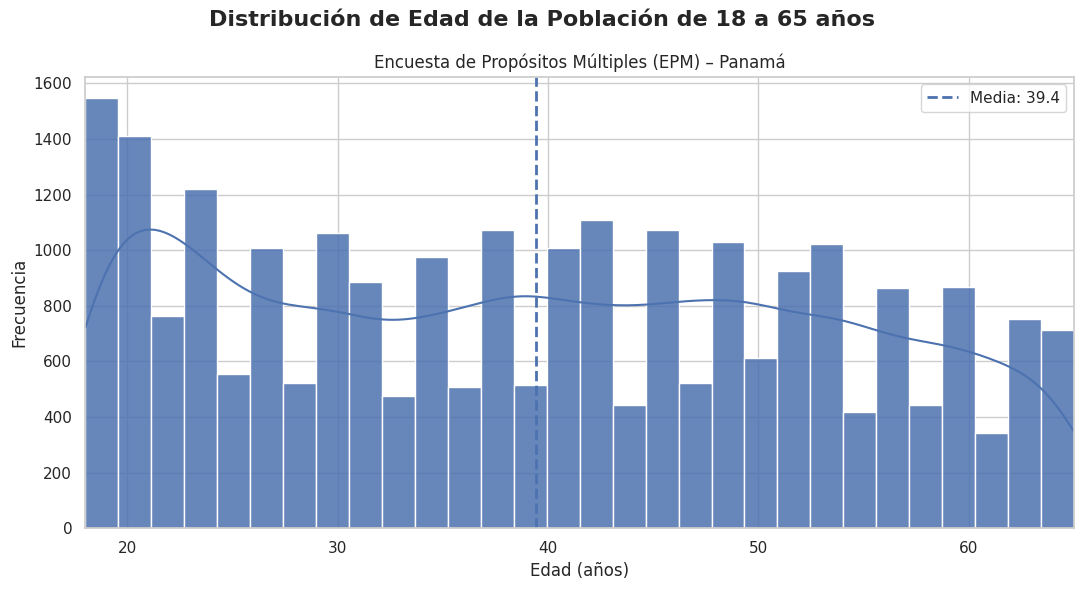

In [88]:
# =========================================
# Distribución de Edad
# =========================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

sns.histplot(
    data=df_analisis,
    x='Edad',
    bins=30,
    kde=True,
    edgecolor='white',
    alpha=0.85
)

media_edad = df_analisis['Edad'].mean()
plt.axvline(
    media_edad,
    linestyle='--',
    linewidth=2,
    label=f'Media: {media_edad:.1f}'
)

plt.suptitle('Distribución de Edad de la Población de 18 a 65 años', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=12)

plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.xlim(EDAD_MIN, EDAD_MAX)

plt.legend()
plt.tight_layout()
plt.show()


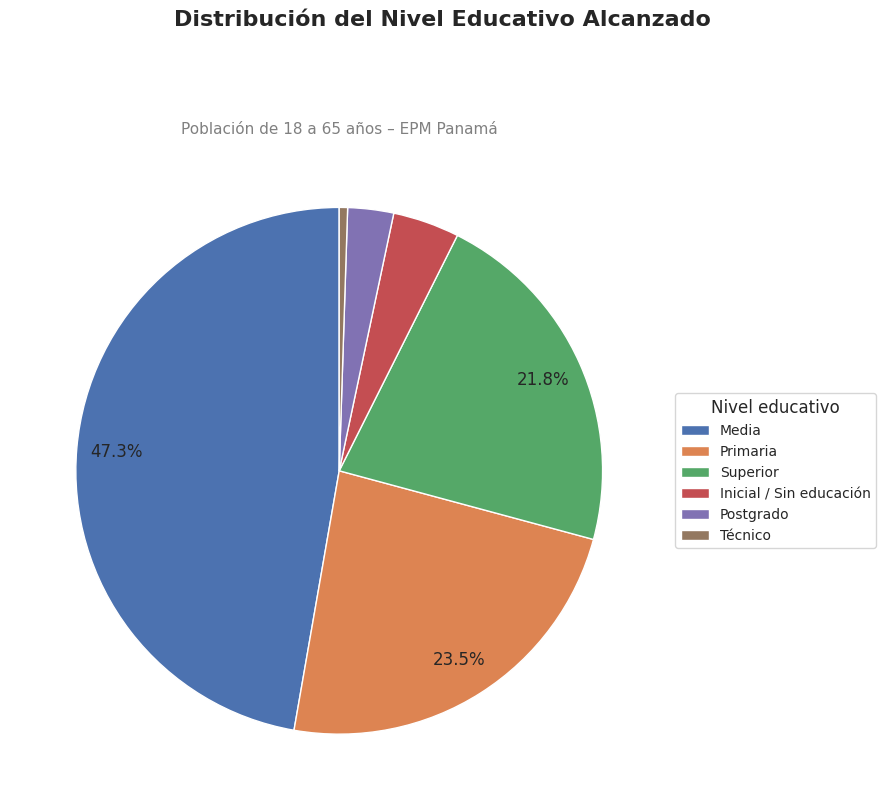

In [89]:
# =========================================
# Distribución del nivel educativo alcanzado
# =========================================

sns.set_theme(style="white")

conteo_educacion = df_analisis['educacion_grupo'].value_counts()

plt.figure(figsize=(9, 9))

wedges, texts, autotexts = plt.pie(
    conteo_educacion,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# Ocultar porcentajes muy pequeños para evitar saturación visual
for i, pct in enumerate(conteo_educacion / conteo_educacion.sum() * 100):
    if pct < 5:
        autotexts[i].set_visible(False)

plt.legend(
    conteo_educacion.index,
    title="Nivel educativo",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.suptitle('Distribución del Nivel Educativo Alcanzado', fontsize=16, fontweight='bold')
plt.title('Población de 18 a 65 años – EPM Panamá', fontsize=11, color='gray')

plt.tight_layout()
plt.show()


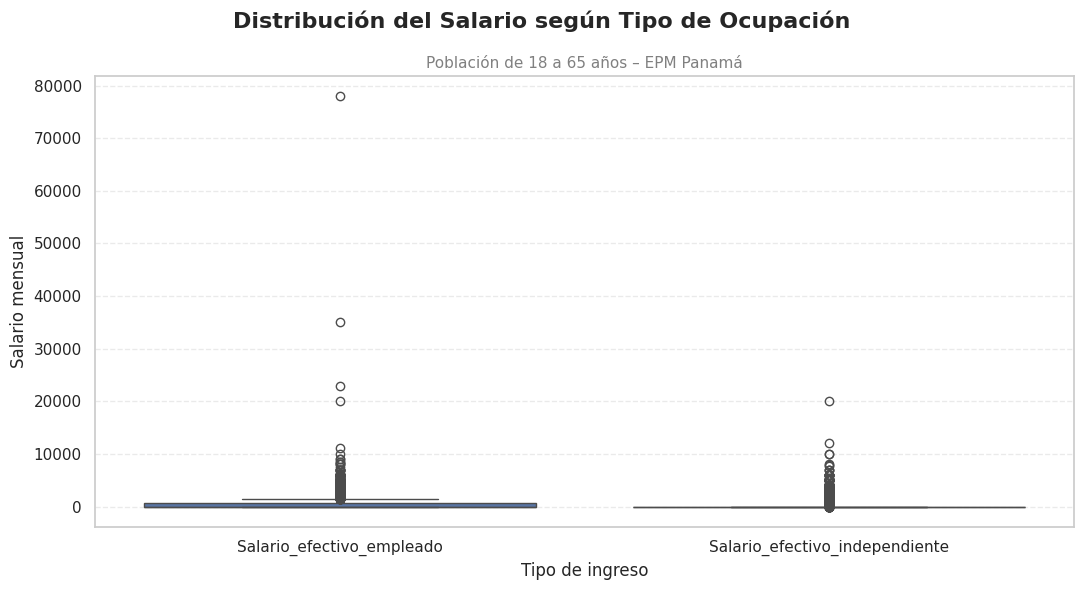

In [90]:
# =========================================
# Distribución del salario según tipo de ocupación
# =========================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df_analisis[['Salario_efectivo_empleado', 'Salario_efectivo_independiente']],
    showfliers=True
)

plt.suptitle('Distribución del Salario según Tipo de Ocupación', fontsize=16, fontweight='bold')
plt.title('Población de 18 a 65 años – EPM Panamá', fontsize=11, color='gray')

plt.xlabel('Tipo de ingreso')
plt.ylabel('Salario mensual')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


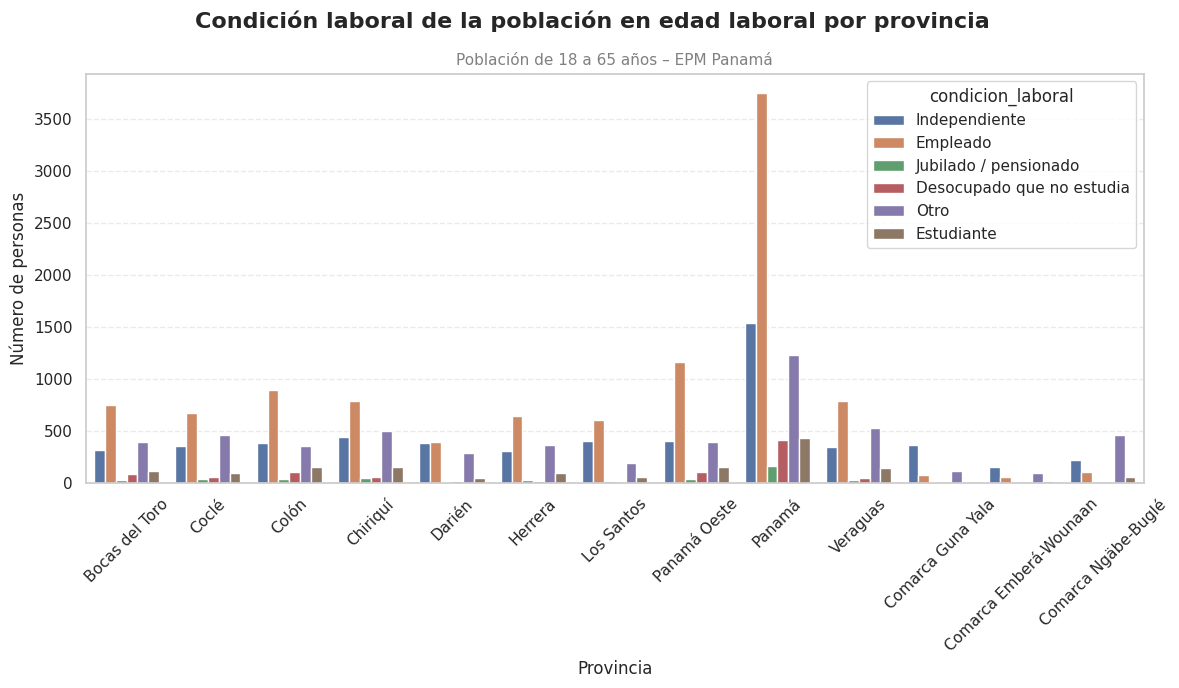

In [91]:
# =========================================
# Condición laboral por provincia
# =========================================

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

sns.countplot(
    data=df_analisis,
    x='provincia',
    hue='condicion_laboral'
)

plt.suptitle('Condición laboral de la población en edad laboral por provincia', fontsize=16, fontweight='bold')
plt.title('Población de 18 a 65 años – EPM Panamá', fontsize=11, color='gray')

plt.xlabel('Provincia')
plt.ylabel('Número de personas')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


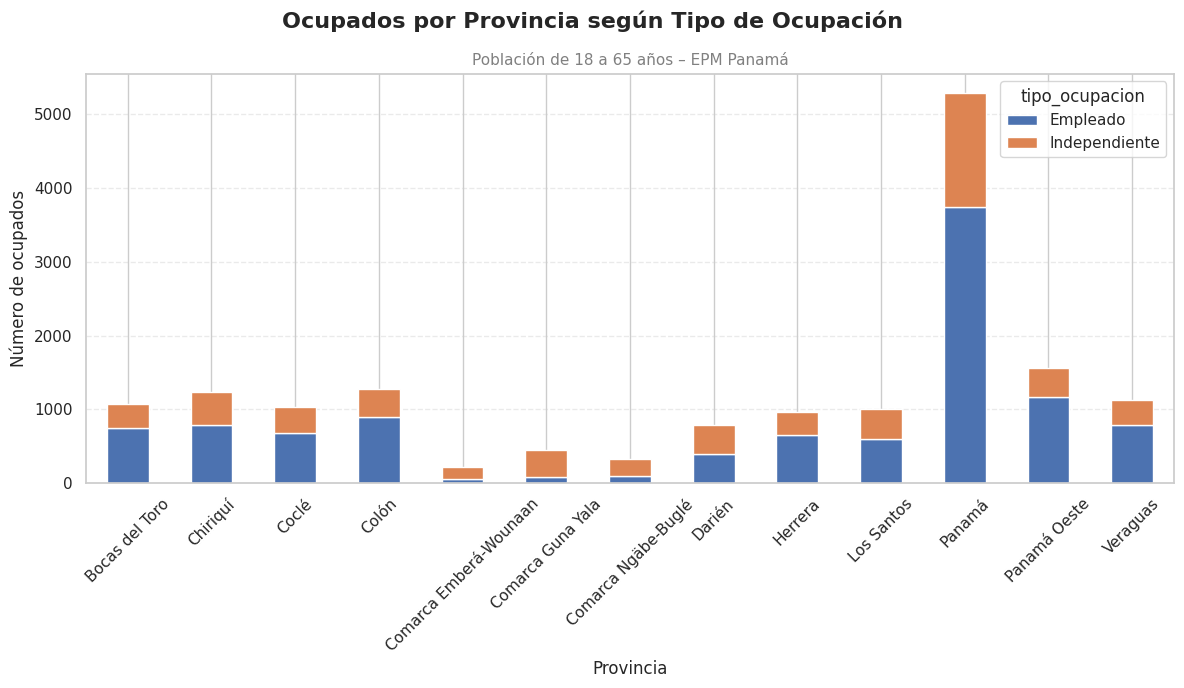

In [92]:
# =========================================
# Ocupados por provincia según tipo de ocupación
# =========================================

sns.set_theme(style="whitegrid")

tabla_ocupacion = pd.crosstab(
    df_analisis.loc[df_analisis['tipo_ocupacion'] != 'Sin ingreso laboral', 'provincia'],
    df_analisis.loc[df_analisis['tipo_ocupacion'] != 'Sin ingreso laboral', 'tipo_ocupacion']
)

tabla_ocupacion.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.suptitle('Ocupados por Provincia según Tipo de Ocupación', fontsize=16, fontweight='bold')
plt.title('Población de 18 a 65 años – EPM Panamá', fontsize=11, color='gray')

plt.xlabel('Provincia')
plt.ylabel('Número de ocupados')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


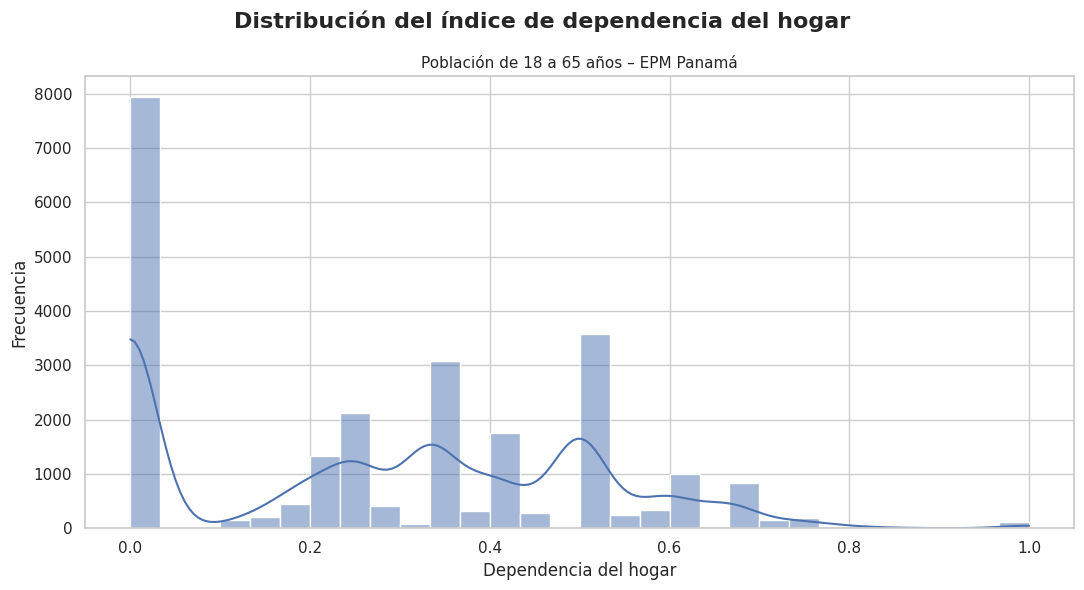

In [93]:
# =========================================
# Distribución del índice de dependencia del hogar
# =========================================

plt.figure(figsize=(11, 6))

sns.histplot(
    data=df_analisis,
    x='dependencia',
    bins=30,
    kde=True
)

plt.suptitle('Distribución del índice de dependencia del hogar', fontsize=16, fontweight='bold')
plt.title('Población de 18 a 65 años – EPM Panamá', fontsize=11)

plt.xlabel('Dependencia del hogar')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


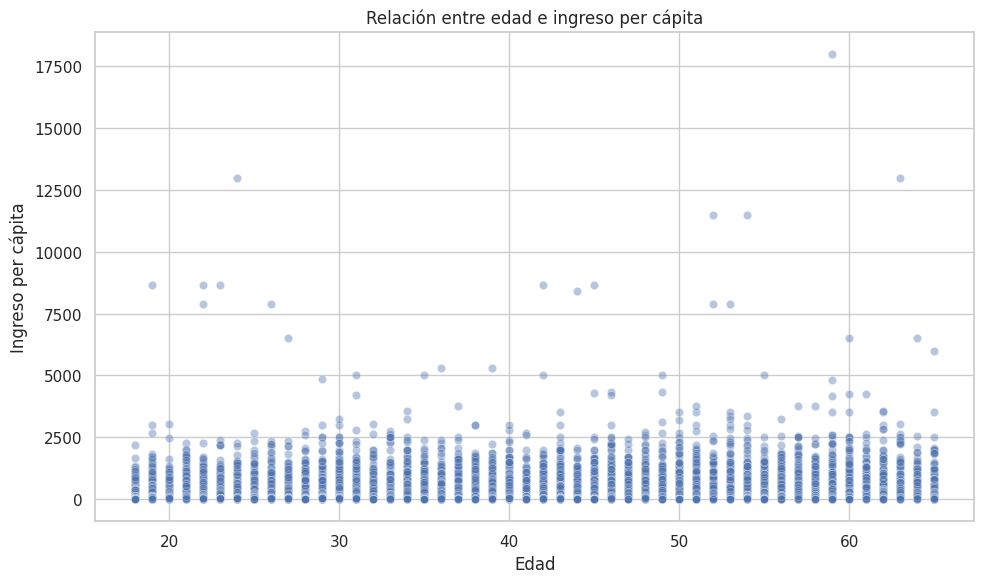

In [94]:
# =========================================
# Edad vs ingreso per cápita
# =========================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_analisis,
    x='Edad',
    y='ingreso_per_capita',
    alpha=0.4
)

plt.title("Relación entre edad e ingreso per cápita")
plt.xlabel("Edad")
plt.ylabel("Ingreso per cápita")

plt.tight_layout()
plt.show()


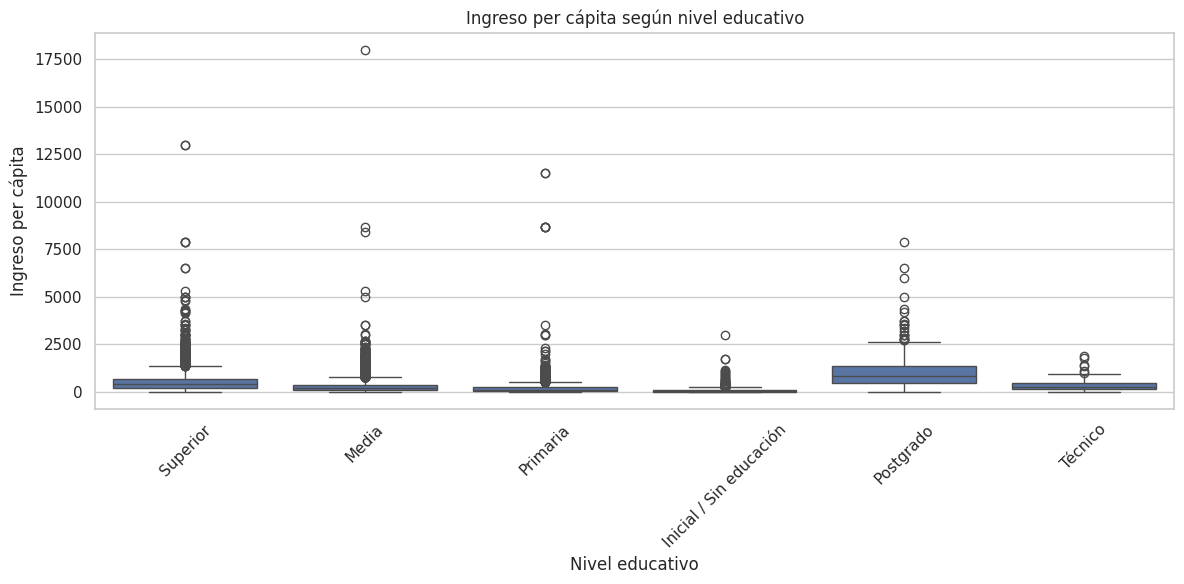

In [95]:
# =========================================
# Educación vs ingreso per cápita
# =========================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_analisis,
    x='educacion_grupo',
    y='ingreso_per_capita'
)

plt.title("Ingreso per cápita según nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Ingreso per cápita")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


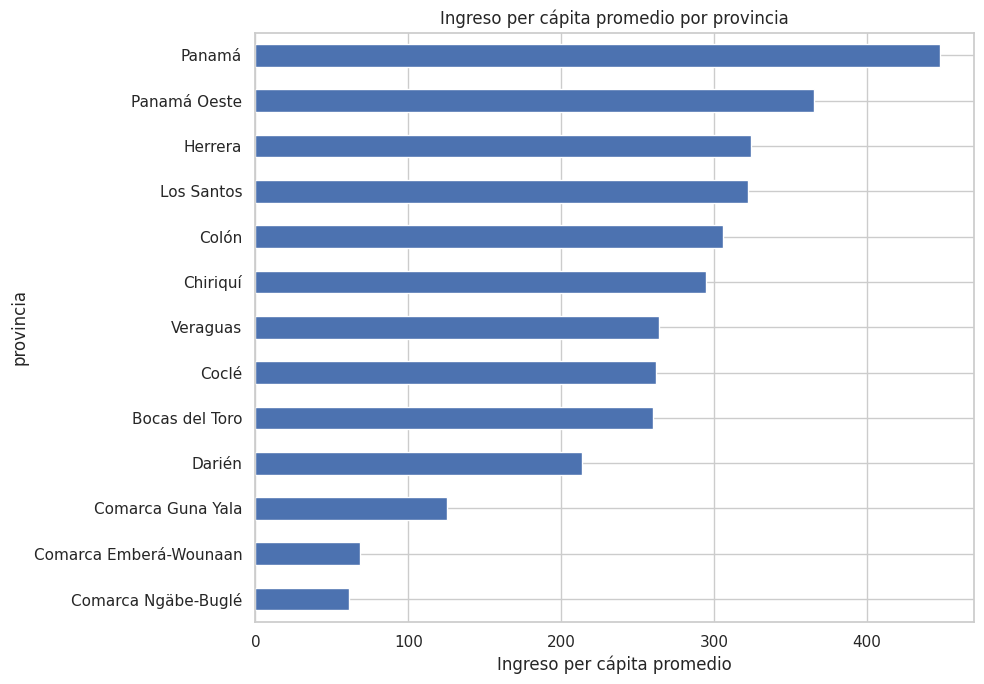

In [96]:
# =========================================
# Ingreso promedio por provincia
# =========================================

ingreso_provincia = (
    df_analisis
    .groupby('provincia')['ingreso_per_capita']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 7))

ingreso_provincia.plot(kind='barh')

plt.title("Ingreso per cápita promedio por provincia")
plt.xlabel("Ingreso per cápita promedio")

plt.tight_layout()
plt.show()


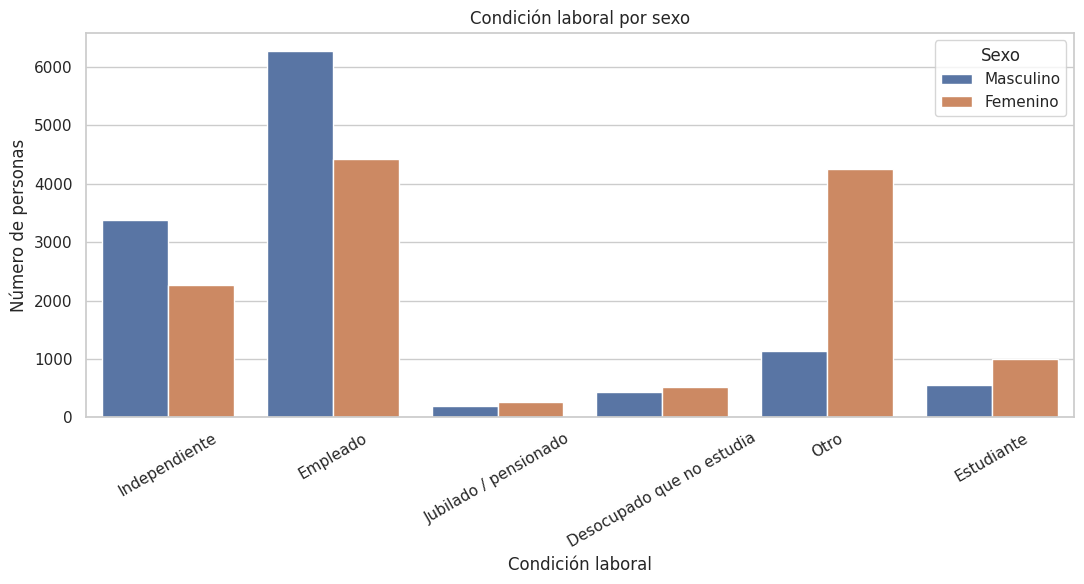

In [97]:
# =========================================
# Condición laboral por sexo
# =========================================

plt.figure(figsize=(11, 6))

sns.countplot(
    data=df_analisis,
    x='condicion_laboral',
    hue='Sexo'
)

plt.title("Condición laboral por sexo")
plt.xlabel("Condición laboral")
plt.ylabel("Número de personas")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


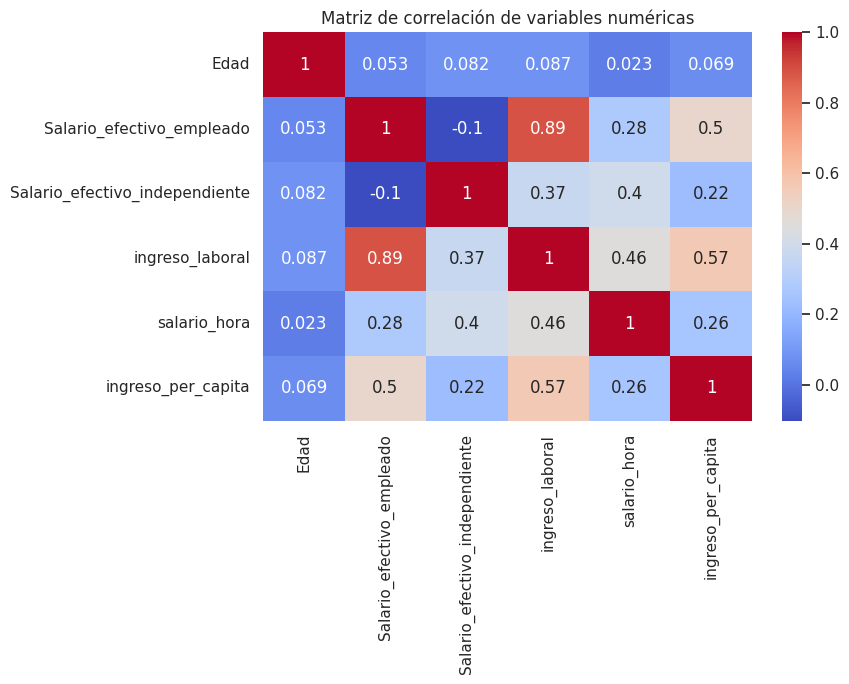

In [98]:
# =========================================
# Correlación entre variables numéricas
# =========================================

variables_numericas = [
    'Edad',
    'Salario_efectivo_empleado',
    'Salario_efectivo_independiente',
    'ingreso_laboral',
    'salario_hora',
    'ingreso_per_capita'
]

variables_numericas = [c for c in variables_numericas if c in df_analisis.columns]

corr = df_analisis[variables_numericas].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


# Modelo Mincer

El modelo se estima usando `df_analisis`.  
Para la regresión se filtran únicamente observaciones válidas: ocupados, ingreso laboral positivo, horas trabajadas positivas y variables completas.

In [99]:
# =========================================
# Descriptivos de variables del modelo Mincer
# =========================================

vars_mincer = [
    'Edad',
    'anios_educacion',
    'experiencia',
    'experiencia2',
    'ingreso_laboral',
    'horas_semana',
    'horas_mensuales',
    'salario_hora',
    'ln_ingreso',
    'ln_salario_hora'
]

mask_mincer = (
    (df_analisis['participa'] == 1) &
    (df_analisis['ingreso_laboral'] > 0) &
    (df_analisis['horas_semana'] > 0) &
    (df_analisis['horas_mensuales'] > 0)
)

datos_mincer = df_analisis.loc[mask_mincer, vars_mincer].dropna().copy()

display(datos_mincer.describe())
print("Observaciones válidas para Mincer:", len(datos_mincer))


,Edad,anios_educacion,experiencia,experiencia2,ingreso_laboral,horas_semana,horas_mensuales,salario_hora,ln_ingreso,ln_salario_hora
count,16341.000000,16341.000000,16341.000000,16341.000000,16341.000000,16341.000000,16341.000000,16341.000000,16341.000000,16341.000000
mean,40.514350,10.735634,21.267793,618.997185,668.907656,37.820696,163.763615,4.461517,5.989585,1.024361
std,12.795343,4.729643,12.910785,586.171791,1015.621591,14.593783,63.191080,19.718108,1.149135,0.960406
min,18.000000,0.000000,0.000000,0.000000,1.000000,1.000000,4.330000,0.004811,0.000000,-5.336769
25%,30.000000,6.000000,10.000000,100.000000,217.000000,30.000000,129.900000,1.847575,5.379897,0.613874
50%,40.000000,12.000000,21.000000,441.000000,550.000000,40.000000,173.200000,3.038775,6.309918,1.111454
75%,51.000000,14.000000,32.000000,1024.000000,800.000000,48.000000,207.840000,4.618938,6.684612,1.530165
max,65.000000,22.000000,47.000000,2209.000000,77940.000000,98.000000,424.340000,2309.468822,11.263695,7.744773


Observaciones válidas para Mincer: 16341


In [100]:
# =========================================
# Estimación del modelo Mincer
# =========================================

X_mincer = datos_mincer[['anios_educacion', 'experiencia', 'experiencia2']]
X_mincer = sm.add_constant(X_mincer)

y_mincer = datos_mincer['ln_ingreso']

modelo_mincer = sm.OLS(y_mincer, X_mincer).fit()

print(modelo_mincer.summary())


                            OLS Regression Results                            
Dep. Variable:             ln_ingreso   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     2334.
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        03:11:17   Log-Likelihood:                -22544.
No. Observations:               16341   AIC:                         4.510e+04
Df Residuals:                   16337   BIC:                         4.513e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1561      0.029    1

# Modelo Heckman

Se mantiene `df_analisis` como dataset principal.  
La primera etapa estima la participación laboral mediante Probit y luego agrega la Razón Inversa de Mills (`IMR`) al mismo `df_analisis`.

In [101]:
# =========================================
# Primera etapa Heckman: Probit de participación
# =========================================

from scipy.stats import norm

vars_seleccion = [
    'Edad',
    'Edad2',
    'sexo_bin',
    'Asiste_a_la_escuela',
    'Recibe_jubilacion_pension',
    'niños',
    'adultos_mayores',
    'ingreso_hogar',
    'estado_civil_rec',
    'jefe_hogar_rec',
    'ingreso_no_laboral',
    'prov',
    'participa'
]

vars_seleccion = [c for c in vars_seleccion if c in df_analisis.columns]

datos_sel = df_analisis[vars_seleccion].copy()

for col in datos_sel.columns:
    datos_sel[col] = pd.to_numeric(datos_sel[col], errors='coerce')

datos_sel = datos_sel.dropna().copy()

X_sel = datos_sel.drop(columns=['participa', 'prov'], errors='ignore')
X_sel = sm.add_constant(X_sel)

y_sel = datos_sel['participa']

probit_model = sm.Probit(y_sel, X_sel)
probit_res = probit_model.fit()

print(probit_res.summary())


Optimization terminated successfully.
         Current function value: 0.474496
         Iterations 22
                          Probit Regression Results                           
Dep. Variable:              participa   No. Observations:                24669
Model:                         Probit   Df Residuals:                    24657
Method:                           MLE   Df Model:                           11
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.1952
Time:                        03:11:18   Log-Likelihood:                -11705.
converged:                       True   LL-Null:                       -14545.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -3.0903      0.117    -26.370      0.000      -3

In [102]:
# =========================================
# Razón Inversa de Mills
# =========================================

datos_sel['xb'] = probit_res.predict(X_sel, linear=True)
datos_sel['IMR'] = norm.pdf(datos_sel['xb']) / norm.cdf(datos_sel['xb'])
datos_sel['IMR'] = datos_sel['IMR'].replace([np.inf, -np.inf], np.nan)

# Guardar IMR dentro del dataset único
df_analisis['IMR'] = np.nan
df_analisis.loc[datos_sel.index, 'IMR'] = datos_sel['IMR']

df_analisis[['Edad', 'participa', 'IMR']].head(10)


,Edad,participa,IMR
0,44.0,1,0.058172
1,21.0,1,0.730528
2,22.0,1,0.654245
3,26.0,1,0.181947
4,34.0,1,0.349380
5,43.0,1,0.080389
6,56.0,1,0.682094
7,59.0,1,0.153928
8,63.0,0,1.256772
9,31.0,1,0.545239


In [103]:
# =========================================
# Segunda etapa Heckman: ecuación salarial
# =========================================

vars_salario = [
    'ln_salario_hora',
    'anios_educacion',
    'experiencia',
    'experiencia2',
    'sexo_bin',
    'antiguedad_anios',
    'IMR',
    'tiene_CSS',
    'horas_mensuales',
    'educacion_grupo',
    'tipo_contrato_eco',
    'tamano_empresa',
    'area_geografica',
    'jornada_categoria',
    'estado_civil_rec',
    'sector_eco_7',
    'provincia',
    'participa'
]

vars_salario = [c for c in vars_salario if c in df_analisis.columns]

datos_wage = df_analisis.loc[df_analisis['participa'] == 1, vars_salario].copy()

cols_dummies = [
    c for c in [
        'educacion_grupo',
        'estado_civil_rec',
        'tipo_contrato_eco',
        'tamano_empresa',
        'jornada_categoria',
        'area_geografica',
        'sector_eco_7',
        'provincia'
    ] if c in datos_wage.columns
]

if cols_dummies:
    datos_wage = pd.get_dummies(
        datos_wage,
        columns=cols_dummies,
        drop_first=True,
        dtype=int
    )

for col in datos_wage.columns:
    datos_wage[col] = pd.to_numeric(datos_wage[col], errors='coerce')

datos_wage = datos_wage.replace([np.inf, -np.inf], np.nan).dropna().copy()

X_wage = datos_wage.drop(columns=['ln_salario_hora', 'participa'], errors='ignore')
X_wage = sm.add_constant(X_wage).astype(float)

y_wage = datos_wage['ln_salario_hora'].astype(float)

wage_model = sm.OLS(y_wage, X_wage).fit()

print(wage_model.summary())


                            OLS Regression Results                            
Dep. Variable:        ln_salario_hora   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     354.9
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        03:11:18   Log-Likelihood:                -17127.
No. Observations:               16341   AIC:                         3.434e+04
Df Residuals:                   16297   BIC:                         3.468e+04
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

# Modelos de clasificación: Logistic Regression, Random Forest y Gradient Boosting

La variable objetivo es `insercion_laboral`, creada dentro de `df_analisis`.

Columnas faltantes: []
Numéricas: ['Edad', 'Edad2', 'sexo_bin', 'anios_educacion', 'estado_civil_rec', 'jefe_hogar_rec', 'niños', 'adultos_mayores', 'ingreso_hogar', 'ingreso_no_laboral']
Categóricas: ['Asiste_a_la_escuela', 'provincia', 'area_geografica']


,Accuracy,Precision,Recall,F1,ROC_AUC
Gradient Boosting,0.944371,0.947747,0.995798,0.971179,0.837671
Random Forest,0.943053,0.943651,0.999160,0.970612,0.827793
Logistic Regression,0.941735,0.942404,0.999160,0.969952,0.800046



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.62      0.02      0.04       223
           1       0.94      1.00      0.97      3570

    accuracy                           0.94      3793
   macro avg       0.78      0.51      0.51      3793
weighted avg       0.92      0.94      0.92      3793


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.77      0.04      0.08       223
           1       0.94      1.00      0.97      3570

    accuracy                           0.94      3793
   macro avg       0.86      0.52      0.53      3793
weighted avg       0.93      0.94      0.92      3793


===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.64      0.12      0.20       223
           1       0.95      1.00      0.97      3570

    accuracy                           0.94      3793
   macro avg       0.80      0.56    

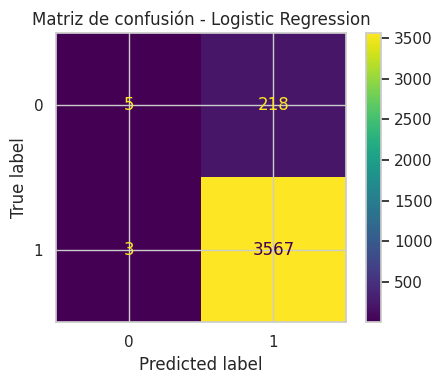

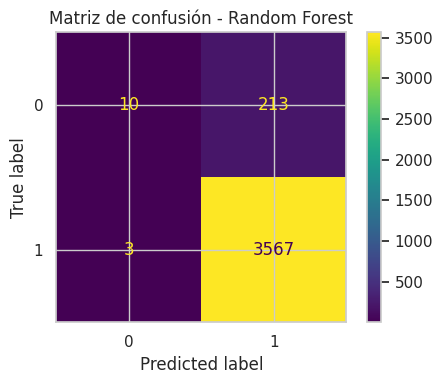

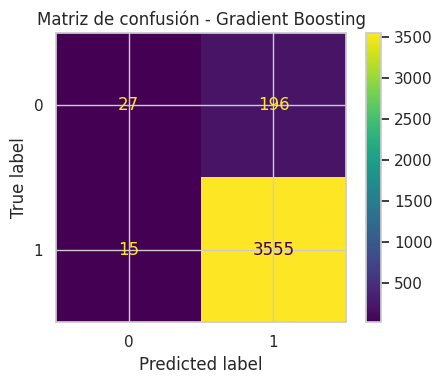

<Figure size 700x500 with 0 Axes>

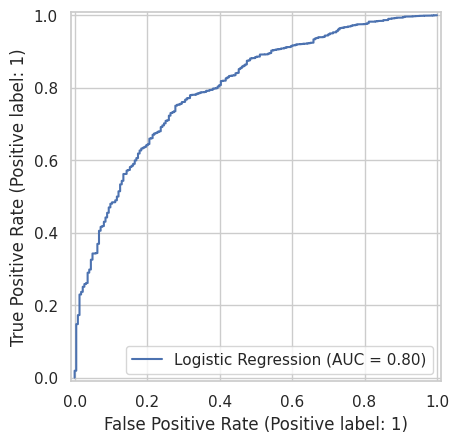

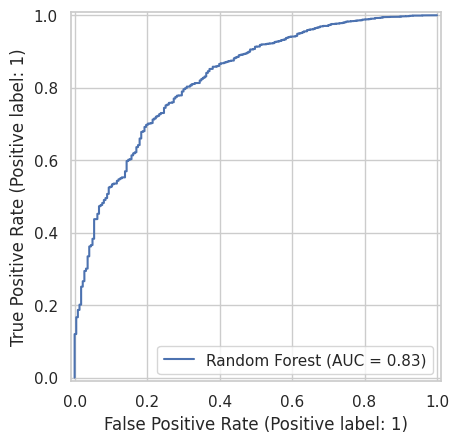

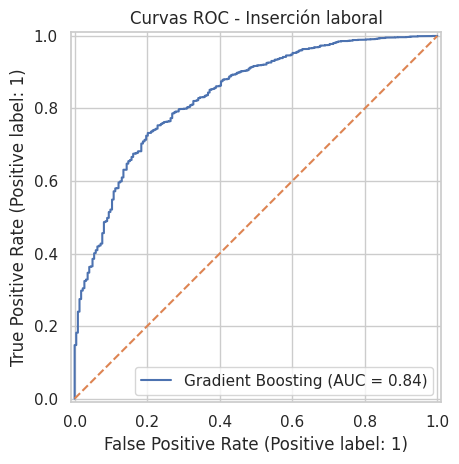

,variable,importancia
8,num__ingreso_hogar,0.244200
0,num__Edad,0.126779
1,num__Edad2,0.125577
3,num__anios_educacion,0.091764
6,num__niños,0.058332
5,num__jefe_hogar_rec,0.057245
9,num__ingreso_no_laboral,0.049702
4,num__estado_civil_rec,0.043515
2,num__sexo_bin,0.043082
23,cat__area_geografica_Urbana,0.038484


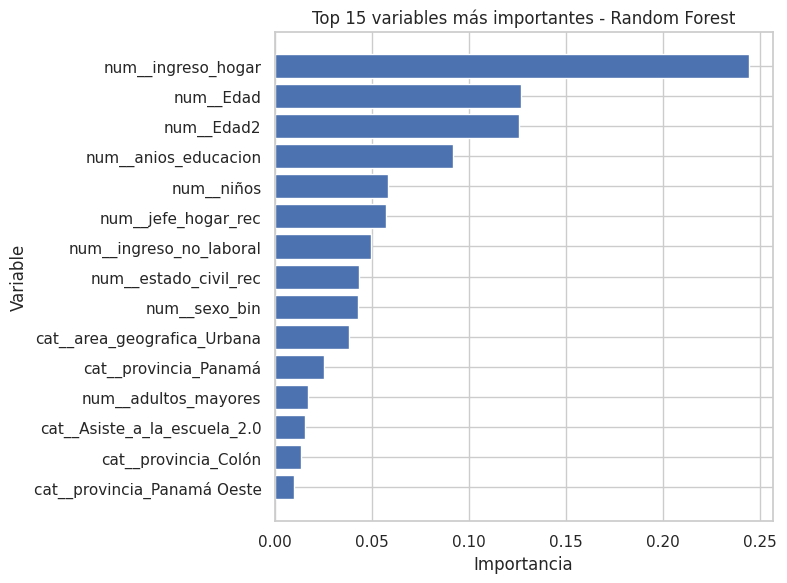

In [104]:
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# =========================================
# 1. Selección de variables
# =========================================

features = [
    'Edad',
    'Edad2',
    'sexo_bin',
    'anios_educacion',
    'Asiste_a_la_escuela',
    'estado_civil_rec',
    'jefe_hogar_rec',
    'niños',
    'adultos_mayores',
    'ingreso_hogar',
    'ingreso_no_laboral',
    'provincia',
    'area_geografica'
]

target = 'insercion_laboral'

features_validas = [c for c in features if c in df_analisis.columns]
faltantes = [c for c in features + [target] if c not in df_analisis.columns]

print("Columnas faltantes:", faltantes)

datos_modelo = df_analisis[features_validas + [target]].copy()
datos_modelo[target] = pd.to_numeric(datos_modelo[target], errors='coerce')
datos_modelo = datos_modelo.dropna(subset=[target]).copy()

# =========================================
# 2. Columnas numéricas y categóricas
# =========================================

num_cols = [
    c for c in [
        'Edad',
        'Edad2',
        'sexo_bin',
        'anios_educacion',
        'estado_civil_rec',
        'jefe_hogar_rec',
        'niños',
        'adultos_mayores',
        'ingreso_hogar',
        'ingreso_no_laboral'
    ] if c in datos_modelo.columns
]

cat_cols = [
    c for c in [
        'Asiste_a_la_escuela',
        'provincia',
        'area_geografica'
    ] if c in datos_modelo.columns
]

for col in num_cols:
    datos_modelo[col] = pd.to_numeric(datos_modelo[col], errors='coerce')

for col in cat_cols:
    datos_modelo[col] = datos_modelo[col].astype('object')

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

X = datos_modelo.drop(columns=[target])
y = datos_modelo[target].astype(int)

# =========================================
# 3. Preprocesamiento
# =========================================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# =========================================
# 4. Train / Test split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================
# 5. Modelos
# =========================================

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# =========================================
# 6. Entrenamiento y evaluación
# =========================================

results = {}
predictions = {}
probas = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_prob)
    }

    predictions[name] = y_pred
    probas[name] = y_prob
    fitted_pipelines[name] = pipe

# =========================================
# 7. Resultados comparativos
# =========================================

results_df = pd.DataFrame(results).T.sort_values(by='ROC_AUC', ascending=False)
display(results_df)

# =========================================
# 8. Classification report
# =========================================

for name in models.keys():
    print(f'\n===== {name} =====')
    print(classification_report(y_test, predictions[name], zero_division=0))

# =========================================
# 9. Matriz de confusión
# =========================================

for name in models.keys():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        ax=ax
    )
    ax.set_title(f'Matriz de confusión - {name}')
    plt.tight_layout()
    plt.show()

# =========================================
# 10. Curvas ROC
# =========================================

plt.figure(figsize=(7, 5))

for name in models.keys():
    RocCurveDisplay.from_predictions(
        y_test,
        probas[name],
        name=name
    )

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curvas ROC - Inserción laboral')
plt.tight_layout()
plt.show()

# =========================================
# 11. Importancia de variables - Random Forest
# =========================================

best_rf = fitted_pipelines['Random Forest']

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'variable': feature_names,
    'importancia': importances
}).sort_values(by='importancia', ascending=False)

display(importance_df.head(15))

top_features = importance_df.head(15).sort_values(by='importancia')

plt.figure(figsize=(8, 6))
plt.barh(top_features['variable'], top_features['importancia'])
plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()
